In [ ]:
pip install pykan


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 4.5 MB/s eta 0:00:00


In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 28.5 MB/s eta 0:00:00


In [ ]:

!pip install tabpfn
!pip install tabpfn-client

# **Modelo TabPFNv2**

In [ ]:
import pandas as pd

def load_data(train_path='train.csv', val_path='validation.csv', test_path='test.csv'):
    """
    Lê os arquivos CSV e separa as features (X) da variável alvo (y).
    """

    # 1. Leitura dos datasets
    df_train = pd.read_csv(train_path)
    df_val = pd.read_csv(val_path)
    df_test = pd.read_csv(test_path)

    # 2. Separação de X e y (O Churn já é numérico 0 e 1 nos CSVs)
    X_train = df_train.drop(columns=['Churn'])
    y_train = df_train['Churn']

    X_val = df_val.drop(columns=['Churn'])
    y_val = df_val['Churn']

    X_test = df_test.drop(columns=['Churn'])
    y_test = df_test['Churn']

    return X_train, y_train, X_val, y_val, X_test, y_test

In [ ]:
import matplotlib.pyplot as plt

def plot_ks_curve(y_true, y_score):
    """
    y_true: valores reais (0 ou 1)
    y_score: probabilidade prevista para a classe positiva
    """

    # Probabilidades de cada classe
    score_0 = np.sort(y_score[y_true == 0])
    score_1 = np.sort(y_score[y_true == 1])

    # Limiar comum
    thresholds = np.sort(np.unique(y_score))

    # ECDF de cada classe
    ecdf_0 = np.searchsorted(score_0, thresholds, side='right') / len(score_0)
    ecdf_1 = np.searchsorted(score_1, thresholds, side='right') / len(score_1)

    # Estatística KS
    diff = np.abs(ecdf_1 - ecdf_0)
    ks = diff.max()
    idx = diff.argmax()
    ks_threshold = thresholds[idx]

    # Plot
    plt.figure(figsize=(8,6))

    plt.plot(
        thresholds,
        ecdf_0,
        label='Classe 0',
        linewidth=2
    )

    plt.plot(
        thresholds,
        ecdf_1,
        label='Classe 1',
        linewidth=2
    )

    # Linha vertical do KS
    plt.vlines(
        ks_threshold,
        ecdf_0[idx],
        ecdf_1[idx],
        colors='black',
        linestyles='dashed',
        linewidth=2,
        label=f'KS = {ks:.3f} em {ks_threshold:.3f}'
    )

    plt.xlabel('Threshold')
    plt.ylabel('Percentual abaixo do threshold')
    plt.title('KS Statistic Plot')

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

    return ks

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import roc_auc_score
import os
from tabpfn_client import TabPFNClassifier, set_access_token

# 1. Carregando os dados do seu script
X_train, y_train, X_val, y_val, X_test, y_test = load_data('/content/drive/MyDrive/Projeto-Churn/data/train.csv', '/content/drive/MyDrive/Projeto-Churn/data/validation.csv', '/content/drive/MyDrive/Projeto-Churn/data/test.csv')

# 2. Configurando sua chave de acesso
set_access_token("chave-api")

# 3. Instanciando o modelo
clf = TabPFNClassifier()

# 4. Treinamento
print("Treinando TabPFNv2 via client...")
clf.fit(X_train, y_train)

# 5. Previsão e Avaliação na Validação
y_val_probs = clf.predict_proba(X_val)

if y_val_probs.ndim == 1:
    auc_val = roc_auc_score(y_val, y_val_probs)
elif y_val_probs.shape[1] == 1:
    auc_val = roc_auc_score(y_val, y_val_probs[:, 0])
else:
    auc_val = roc_auc_score(y_val, y_val_probs[:, 1])

print(f"TabPFNv2 - ROC-AUC na Validação: {auc_val:.4f}")


Treinando TabPFNv2 via client...
00:00 Fitting... |

00:05 Fitting... Done!
00:00 Predicting... \

00:03 Predicting... Done!
TabPFNv2 - ROC-AUC na Validação: 0.8543


=== Curva KS ===


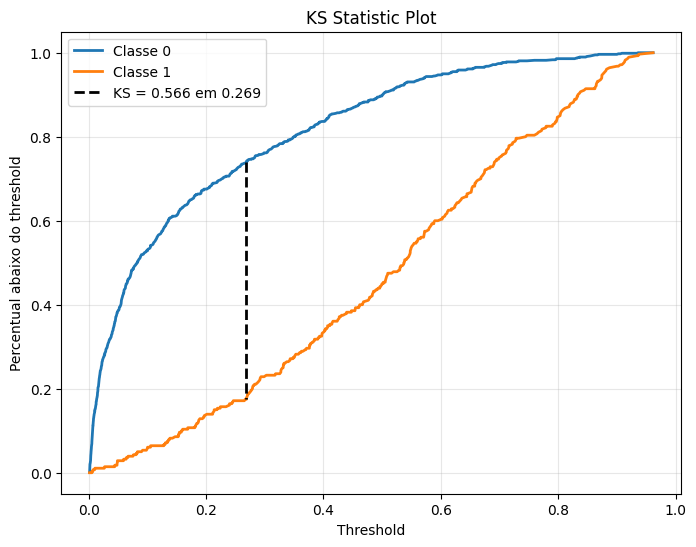


=== Métricas de Desempenho ===


,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,0.8059,0.6609,0.55,0.6004,0.8543


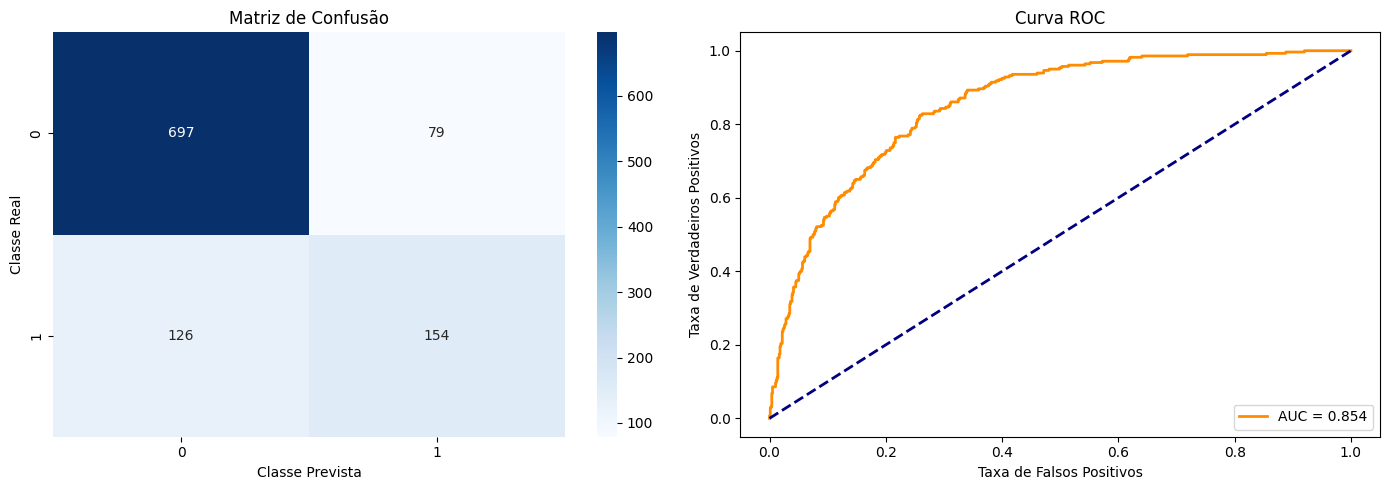

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

# 1. Garantir que as probabilidades sejam 1D
if y_val_probs.ndim == 2:
    if y_val_probs.shape[1] == 2:
        y_probs_1d = y_val_probs[:, 1]
    else:
        y_probs_1d = y_val_probs[:, 0]
else:
    y_probs_1d = y_val_probs

y_probs_1d = np.ravel(y_probs_1d) # Achata o array para garantir compatibilidade

# 2. Plotar a Curva KS (usando sua função)
print("=== Curva KS ===")
ks_tabpfn = plot_ks_curve(y_val, y_probs_1d)

# 3. Gerar previsões binárias (usando limiar padrão de 0.5)
y_val_preds = (y_probs_1d >= 0.5).astype(int)

# 4. Calcular Métricas
metrics = {
    "Accuracy": accuracy_score(y_val, y_val_preds),
    "Precision": precision_score(y_val, y_val_preds),
    "Recall": recall_score(y_val, y_val_preds),
    "F1-score": f1_score(y_val, y_val_preds),
    "ROC-AUC": roc_auc_score(y_val, y_probs_1d)
}

print("\n=== Métricas de Desempenho ===")
metrics_df = pd.DataFrame([metrics]).round(4)
display(metrics_df)

# 5. Plotar Matriz de Confusão e Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Matriz de Confusão
cm = confusion_matrix(y_val, y_val_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusão')
axes[0].set_xlabel('Classe Prevista')
axes[0].set_ylabel('Classe Real')

# Plot Curva ROC
fpr, tpr, thresholds = roc_curve(y_val, y_probs_1d)
axes[1].plot(fpr, tpr, lw=2, color='darkorange', label=f"AUC = {metrics['ROC-AUC']:.3f}")
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('Taxa de Falsos Positivos')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

Gerando previsões para o conjunto de Teste...
00:08 Predicting... Done!

=== Curva KS (Teste) ===


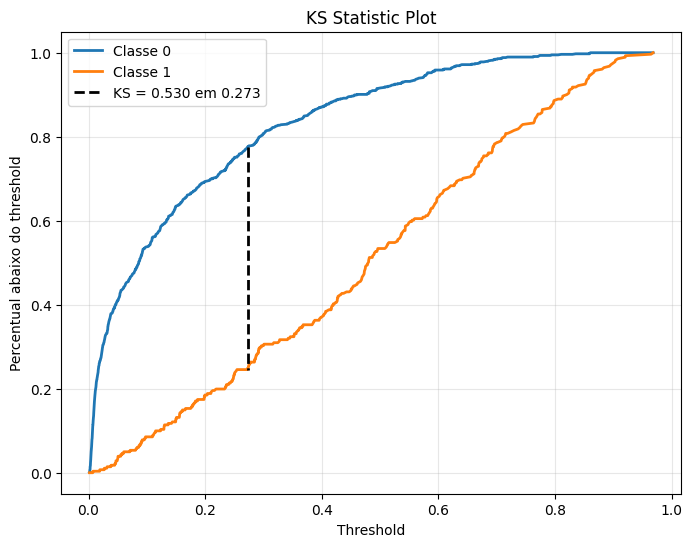


=== Métricas de Desempenho (Teste) ===


,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,0.7956,0.665,0.4662,0.5481,0.8459


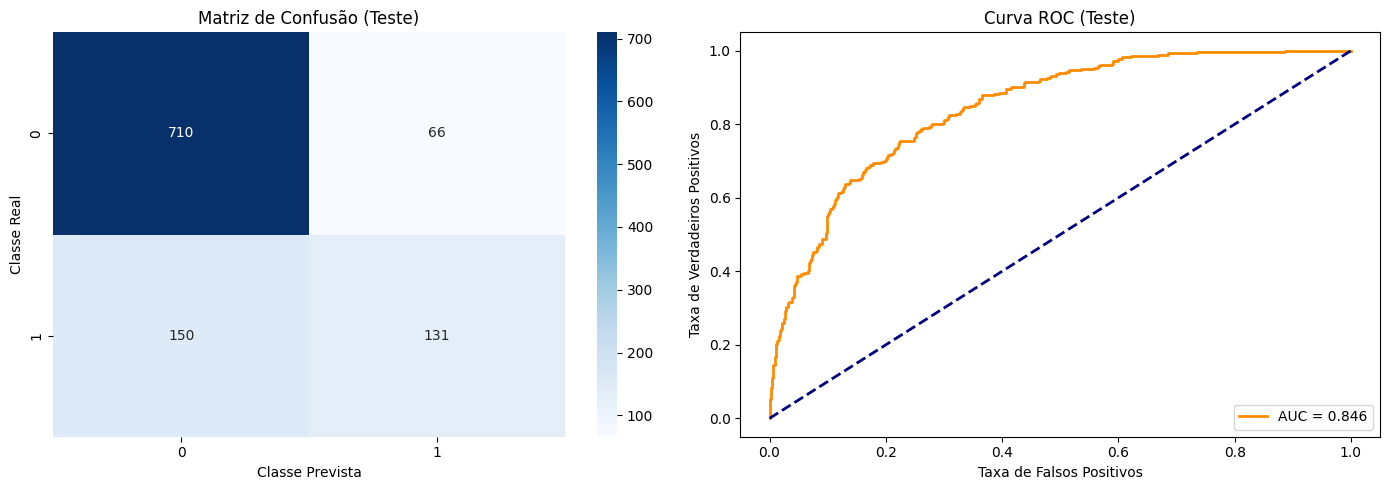

In [ ]:
# ==========================================================
# AVALIAÇÃO DO MODELO TABPFN NO CONJUNTO DE TESTE
# ==========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

print("Gerando previsões para o conjunto de Teste...")
# 1. Previsão e extração de probabilidades
y_test_probs = clf.predict_proba(X_test)

# Garantir que as probabilidades sejam 1D (focando na classe positiva)
if y_test_probs.ndim == 2:
    if y_test_probs.shape[1] == 2:
        y_test_probs_1d = y_test_probs[:, 1]
    else:
        y_test_probs_1d = y_test_probs[:, 0]
else:
    y_test_probs_1d = y_test_probs

y_test_probs_1d = np.ravel(y_test_probs_1d)

# 2. Plotar a Curva KS
print("\n=== Curva KS (Teste) ===")
ks_tabpfn_test = plot_ks_curve(y_test, y_test_probs_1d)

# 3. Gerar previsões binárias (limiar de 0.5)
y_test_preds = (y_test_probs_1d >= 0.5).astype(int)

# 4. Calcular Métricas para o Teste
metrics_test = {
    "Accuracy": accuracy_score(y_test, y_test_preds),
    "Precision": precision_score(y_test, y_test_preds),
    "Recall": recall_score(y_test, y_test_preds),
    "F1-score": f1_score(y_test, y_test_preds),
    "ROC-AUC": roc_auc_score(y_test, y_test_probs_1d)
}

print("\n=== Métricas de Desempenho (Teste) ===")
metrics_test_df = pd.DataFrame([metrics_test]).round(4)
display(metrics_test_df)

# 5. Plotar Matriz de Confusão e Curva ROC para o Teste
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de Confusão
cm_test = confusion_matrix(y_test, y_test_preds)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusão (Teste)')
axes[0].set_xlabel('Classe Prevista')
axes[0].set_ylabel('Classe Real')

# Curva ROC
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_probs_1d)
axes[1].plot(fpr_test, tpr_test, lw=2, color='darkorange', label=f"AUC = {metrics_test['ROC-AUC']:.3f}")
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('Curva ROC (Teste)')
axes[1].set_xlabel('Taxa de Falsos Positivos')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# **Modelo STab (com otimização via Optuna)**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import roc_auc_score
import copy
import numpy as np
import pandas as pd

# ==========================================
# 1. Arquitetura da Rede Neural (PyTorch)
# ==========================================
class STabNet(nn.Module):
    def __init__(self, num_cont, cat_cardinalities, dim=64, depth=3, heads=4, attn_dropout=0.0, ff_dropout=0.0):
        super().__init__()
        self.num_cont = num_cont
        self.num_cat = len(cat_cardinalities)

        # Embeddings para variáveis categóricas
        self.cat_embeds = nn.ModuleList([nn.Embedding(c, dim) for c in cat_cardinalities])

        # Embeddings para variáveis contínuas (projetando 1 valor para 'dim' dimensões)
        self.num_embed = nn.ModuleList([nn.Linear(1, dim) for _ in range(num_cont)])

        # CLS Token (Usado para agregar a informação tabular e fazer a previsão final)
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=heads,
            dropout=attn_dropout,
            dim_feedforward=dim * 4,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # Head de Classificação Binária
        self.head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Dropout(ff_dropout),
            nn.Linear(dim, 1)
        )

    def forward(self, x_cont, x_cat):
        embeds = []

        # Processa variáveis categóricas
        if self.num_cat > 0:
            for i, emb in enumerate(self.cat_embeds):
                embeds.append(emb(x_cat[:, i]))

        # Processa variáveis contínuas
        if self.num_cont > 0:
            for i, emb in enumerate(self.num_embed):
                embeds.append(emb(x_cont[:, i].unsqueeze(1)))

        # Concatena todos os embeddings [Batch, Num_Features, Dim]
        x = torch.stack(embeds, dim=1)

        # Adiciona o CLS token no início da sequência
        b = x.shape[0]
        cls_tokens = self.cls_token.expand(b, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        # Passa pelo Transformer
        x = self.transformer(x)

        # Pega apenas a saída do CLS token para a classificação
        cls_out = x[:, 0, :]

        # Retorna o Logit (A função de loss cuidará do Sigmoid)
        return self.head(cls_out).squeeze(-1)

# ==========================================
# 2. Wrapper Scikit-Learn (Para o Optuna)
# ==========================================
class STabClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, cat_idxs=None, dim=64, depth=3, heads=4, attn_dropout=0.0,
                 ff_dropout=0.0, lr=1e-3, weight_decay=1e-4, batch_size=256,
                 max_epochs=100, patience=20, device='cuda', **kwargs):

        self.cat_idxs = cat_idxs if cat_idxs is not None else []
        self.dim = dim
        self.depth = depth
        self.heads = heads
        self.attn_dropout = attn_dropout
        self.ff_dropout = ff_dropout
        self.lr = lr
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.patience = patience
        self.device = device if torch.cuda.is_available() else 'cpu'

        # Captura hiperparâmetros extras (como U, cases, sample_size)
        self.kwargs = kwargs
        self.history_ = {'train_loss': [], 'val_loss': [], 'val_auc': []}

    def _prepare_data(self, X):
        # Converte para Numpy se for Pandas
        if isinstance(X, pd.DataFrame):
            X = X.values

        num_idxs = [i for i in range(X.shape[1]) if i not in self.cat_idxs]
        x_cont = torch.tensor(X[:, num_idxs], dtype=torch.float32)
        x_cat = torch.tensor(X[:, self.cat_idxs], dtype=torch.long)
        return x_cont, x_cat

    def fit(self, X, y, eval_set=None, verbose=False):
        # Configura as cardinalidades das variáveis categóricas
        if isinstance(X, pd.DataFrame):
            X_np = X.values
        else:
            X_np = X

        self.cat_cardinalities_ = []
        for idx in self.cat_idxs:
            self.cat_cardinalities_.append(int(np.max(X_np[:, idx])) + 2)

        self.num_cont_ = X_np.shape[1] - len(self.cat_idxs)

        # Instancia o modelo PyTorch
        self.model_ = STabNet(
            num_cont=self.num_cont_,
            cat_cardinalities=self.cat_cardinalities_,
            dim=self.dim, depth=self.depth, heads=self.heads,
            attn_dropout=self.attn_dropout, ff_dropout=self.ff_dropout
        ).to(self.device)

        # Prepara dados
        x_cont, x_cat = self._prepare_data(X)
        y_tensor = torch.tensor(y.values if isinstance(y, pd.Series) else y, dtype=torch.float32)

        dataset = TensorDataset(x_cont, x_cat, y_tensor)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        if eval_set:
            x_cont_val, x_cat_val = self._prepare_data(eval_set[0][0])
            y_val_tensor = torch.tensor(eval_set[0][1].values if isinstance(eval_set[0][1], pd.Series) else eval_set[0][1], dtype=torch.float32)
            val_dataset = TensorDataset(x_cont_val, x_cat_val, y_val_tensor)
            val_dataloader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)

        optimizer = optim.AdamW(self.model_.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        criterion = nn.BCEWithLogitsLoss()

        best_val_loss = float('inf')
        patience_counter = 0
        best_weights = None

        for epoch in range(self.max_epochs):
            self.model_.train()
            train_loss = 0

            for bc_cont, bc_cat, by in dataloader:
                bc_cont, bc_cat, by = bc_cont.to(self.device), bc_cat.to(self.device), by.to(self.device)

                optimizer.zero_grad()
                logits = self.model_(bc_cont, bc_cat)
                loss = criterion(logits, by)
                loss.backward()
                optimizer.step()

                train_loss += loss.item() * len(by)

            train_loss /= len(dataset)
            self.history_['train_loss'].append(train_loss)

            if eval_set:
                self.model_.eval()
                val_loss = 0
                val_preds = []
                val_targets = []

                with torch.no_grad():
                    for bc_cont, bc_cat, by in val_dataloader:
                        bc_cont, bc_cat, by = bc_cont.to(self.device), bc_cat.to(self.device), by.to(self.device)
                        logits = self.model_(bc_cont, bc_cat)
                        loss = criterion(logits, by)
                        val_loss += loss.item() * len(by)
                        val_preds.extend(torch.sigmoid(logits).cpu().numpy())
                        val_targets.extend(by.cpu().numpy())

                val_loss /= len(val_dataset)
                val_auc = roc_auc_score(val_targets, val_preds)
                self.history_['val_loss'].append(val_loss)
                self.history_['val_auc'].append(val_auc)

                if verbose and epoch % 10 == 0:
                    print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f}")

                # Early Stopping
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                    best_weights = copy.deepcopy(self.model_.state_dict())
                else:
                    patience_counter += 1
                    if patience_counter >= self.patience:
                        if verbose:
                            print(f"Early stopping at epoch {epoch}")
                        break

        # Restaura os melhores pesos da validação
        if best_weights is not None:
            self.model_.load_state_dict(best_weights)

        return self

    def predict_proba(self, X):
        self.model_.eval()
        x_cont, x_cat = self._prepare_data(X)
        dataset = TensorDataset(x_cont, x_cat)
        dataloader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)

        probs = []
        with torch.no_grad():
            for bc_cont, bc_cat in dataloader:
                bc_cont, bc_cat = bc_cont.to(self.device), bc_cat.to(self.device)
                logits = self.model_(bc_cont, bc_cat)
                prob = torch.sigmoid(logits).cpu().numpy()
                probs.extend(prob)

        probs = np.array(probs)
        return np.vstack((1 - probs, probs)).T

    def predict(self, X):
        probs = self.predict_proba(X)[:, 1]
        return (probs >= 0.5).astype(int)

/tmp/ipykernel_1194/577240686.py:92: ExperimentalWarning: GPSampler is experimental (supported from v3.6.0). The interface can change in the future.
  sampler=optuna.samplers.GPSampler(seed=42)
[I 2026-07-03 07:13:24,523] A new study created in memory with name: no-name-b4136f32-4959-4560-b68f-18ae7b606658


Configurando e aplicando o pré-processamento...
Pré-processamento concluído! O dataset tem 3 colunas numéricas e 14 categóricas.


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-07-03 07:13:46,661] Trial 0 finished with value: 0.5502209131075111 and parameters: {'dim': 64, 'depth': 3, 'heads': 2, 'attn_dropout': 0.4330880728874676, 'ff_dropout': 0.3005575058716044, 'U': 3, 'cases': 2, 'lr': 0.00026587543983272726, 'weight_decay': 3.5113563139704077e-06, 'batch_size': 128, 'sample_size': 64}. Best is trial 0 with value: 0.5502209131075111.
[I 2026-07-03 07:13:53,805] Trial 1 finished with value: 0.37485272459499264 and parameters: {'dim': 128, 'depth': 2, 'heads': 2, 'attn_dropout': 0.29620728443102123, 'ff_dropout': 0.023225206359998862, 'U': 3, 'cases': 3, 'lr': 0.00853618986286683, 'weight_decay': 0.0002661901888489054, 'batch_size': 128, 'sample_size': 64}. Best is trial 0 with value: 0.5502209131075111.
[I 2026-07-03 07:14:02,612] Trial 2 finished with value: 0.4657952871870398 and parameters: {'dim': 64, 'depth': 3, 'heads': 8, 'attn_dropout': 0.09242722776276352, 'ff_dropout': 0.4847923138822793, 'U': 4, 'cases': 1, 'lr': 0.0069782812651260325, '

,Accuracy,Precision,Recall,F1-score,ROC-AUC,KS-Stat
0,0.803,0.6875,0.4714,0.5593,0.8516,0.5608


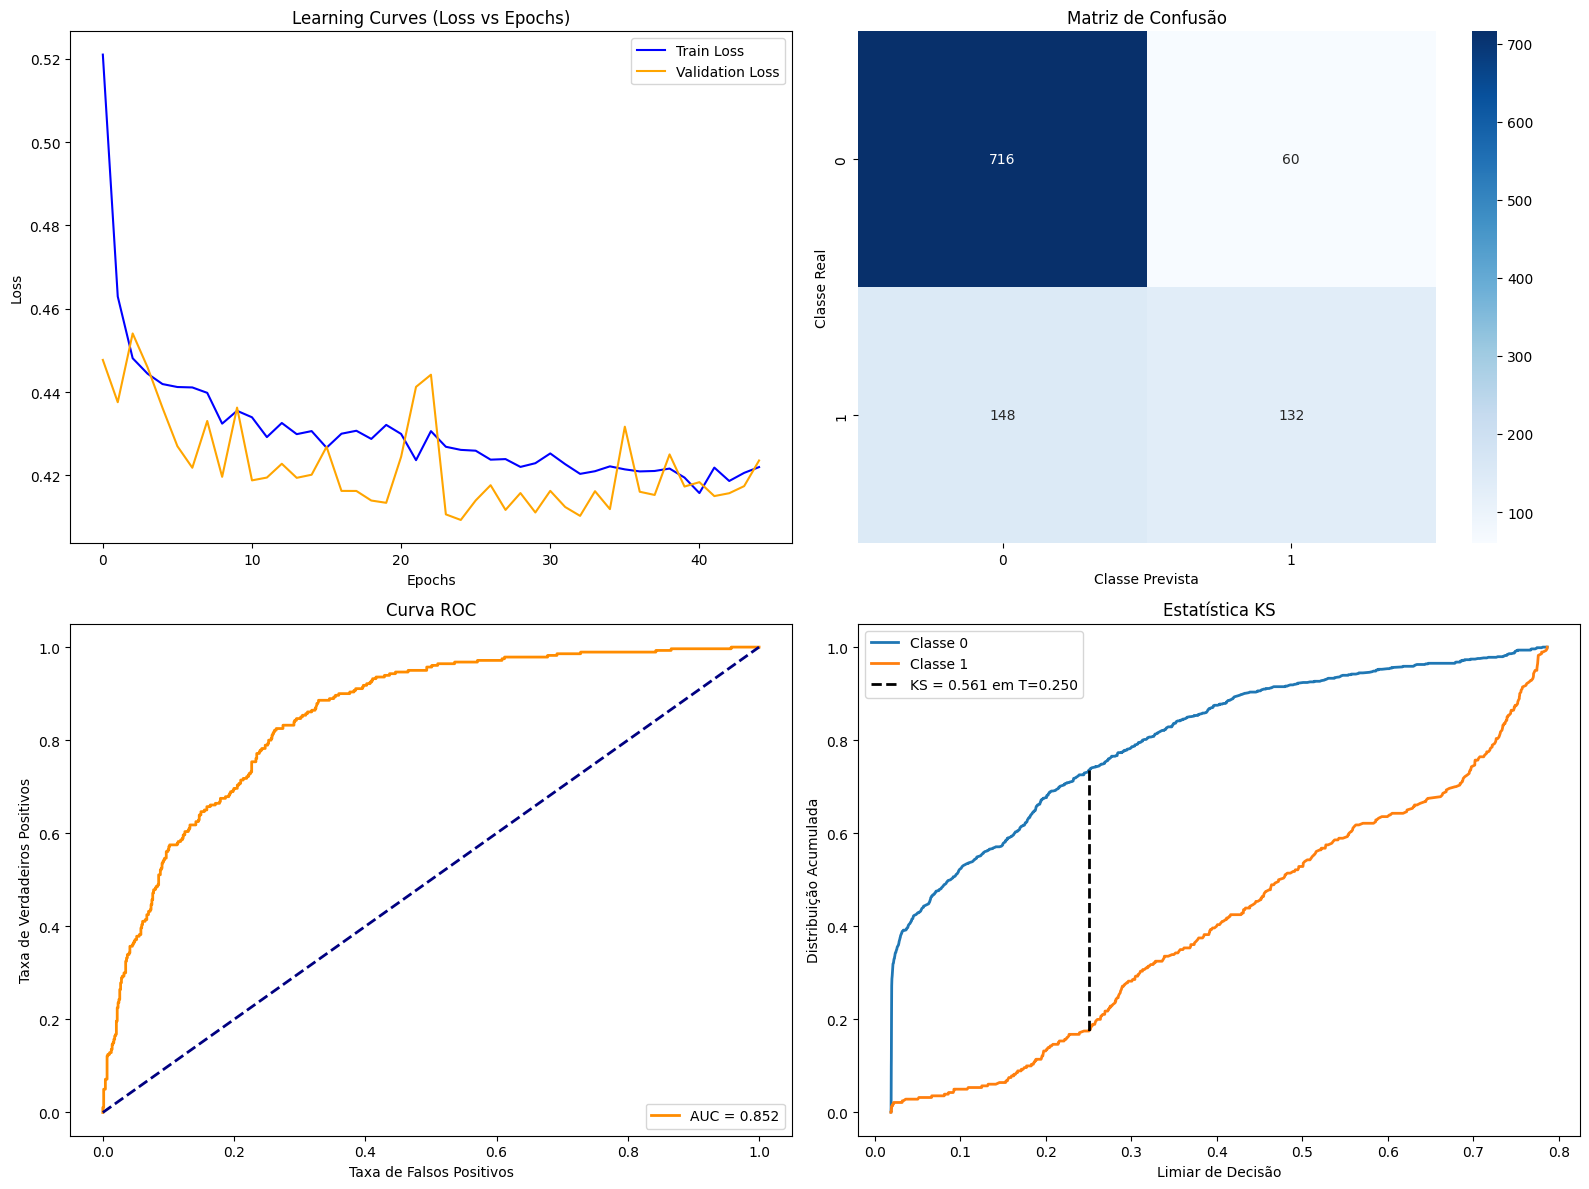

In [ ]:
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

print("Configurando e aplicando o pré-processamento...")

# 1.1 Definindo quais são as colunas numéricas e pegando o resto automaticamente como categóricas
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Pega dinamicamente todas as colunas presentes em X_train que não estão na lista de numéricas
cat_cols = [col for col in X_train.columns if col not in num_cols]

# 1.2 Criando os pipelines de transformação
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# 1.3 Unindo tudo no preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# 1.4 Aplicando o pré-processamento (Fit apenas no treino!)
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)

print(f"Pré-processamento concluído! O dataset tem {len(num_cols)} colunas numéricas e {len(cat_cols)} categóricas.")

# 2. Definindo a Função Objetivo para o Optuna (Maximizando o KS)
num_cols_len = len(['tenure', 'MonthlyCharges', 'TotalCharges'])
cat_idxs = list(range(num_cols_len, X_train_proc.shape[1]))

# 2. Definindo a Função Objetivo (AJUSTADA)
def objective_stab(trial):
    params = {
        "dim": trial.suggest_categorical("dim", [32, 64, 128]),
        "depth": trial.suggest_int("depth", 1, 4),
        "heads": trial.suggest_categorical("heads", [2, 4, 8]),
        "attn_dropout": trial.suggest_float("attn_dropout", 0.0, 0.5),
        "ff_dropout": trial.suggest_float("ff_dropout", 0.0, 0.5),
        "U": trial.suggest_int("U", 1, 4),
        "cases": trial.suggest_categorical("cases", [1, 2, 3]),
        "lr": trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128]),
        "sample_size": trial.suggest_categorical("sample_size", [16, 32, 64])
    }

    model_stab = STabClassifier(
        cat_idxs=cat_idxs,
        **params,
        max_epochs=200,
        patience=5,
        device='cuda',
        random_state=42
    )

    model_stab.fit(X_train_proc, y_train, eval_set=[(X_val_proc, y_val)], verbose=False)

    preds_proba = np.ravel(model_stab.predict_proba(X_val_proc)[:, 1])
    ks_stat = ks_2samp(preds_proba[y_val == 0], preds_proba[y_val == 1]).statistic

    return ks_stat

# Execução do Optuna (Sugerido usar o GPSampler como no seu histórico de projeto)
study_stab = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.GPSampler(seed=42)
)
study_stab.optimize(objective_stab, n_trials=10, show_progress_bar=True)

print("\nMelhores parâmetros encontrados:")
print(study_stab.best_params)

print(f"Melhor Score KS (Validação): {study_stab.best_value:.4f}")

# =====================================================================
# 4. RETREINAMENTO COM O MELHOR MODELO E GERAÇÃO DE GRÁFICOS
# =====================================================================
print("\nRetreinando o melhor modelo para extrair métricas e gráficos...")

best_model_stab = STabClassifier(
    **study_stab.best_params,
    max_epochs=1000,
    patience=20,
    device='cuda',
    random_state=42
)

# Capturando o histórico (A forma como a loss é salva depende da sua biblioteca STab)
history = best_model_stab.fit(
    X_train_proc, y_train,
    eval_set=[(X_val_proc, y_val)],
    verbose=True
)

# Previsões na validação
y_probs = np.ravel(best_model_stab.predict_proba(X_val_proc)[:, 1])
y_preds = (y_probs >= 0.5).astype(int)

# Cálculo de Métricas Clássicas
metrics = {
    "Accuracy": accuracy_score(y_val, y_preds),
    "Precision": precision_score(y_val, y_preds),
    "Recall": recall_score(y_val, y_preds),
    "F1-score": f1_score(y_val, y_preds),
    "ROC-AUC": roc_auc_score(y_val, y_probs),
    "KS-Stat": ks_2samp(y_probs[y_val == 0], y_probs[y_val == 1]).statistic
}

print("\n=== Métricas de Desempenho (Melhor Modelo STab) ===")
display(pd.DataFrame([metrics]).round(4))

# ---------------- PLOTS ----------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Gráfico de Loss (Erro) de Treino e Validação
try:
    train_loss = best_model_stab.history_['train_loss']
    val_loss = best_model_stab.history_['val_loss']
    axes[0, 0].plot(train_loss, label='Train Loss', color='blue')
    axes[0, 0].plot(val_loss, label='Validation Loss', color='orange')
    axes[0, 0].set_title('Learning Curves (Loss vs Epochs)')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
except:
    axes[0, 0].text(0.5, 0.5, 'Histórico de Loss não encontrado.\nVerifique a API do STab.', ha='center')
    axes[0, 0].set_title('Learning Curves (Loss vs Epochs)')

# 2. Matriz de Confusão
cm = confusion_matrix(y_val, y_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1])
axes[0, 1].set_title('Matriz de Confusão')
axes[0, 1].set_xlabel('Classe Prevista')
axes[0, 1].set_ylabel('Classe Real')

# 3. Curva ROC
fpr, tpr, _ = roc_curve(y_val, y_probs)
axes[1, 0].plot(fpr, tpr, lw=2, color='darkorange', label=f"AUC = {metrics['ROC-AUC']:.3f}")
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1, 0].set_title('Curva ROC')
axes[1, 0].set_xlabel('Taxa de Falsos Positivos')
axes[1, 0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1, 0].legend(loc="lower right")

# 4. Curva KS
# Recriando a lógica do plot_ks_curve diretamente no subplot para manter tudo alinhado
score_0 = np.sort(y_probs[y_val == 0])
score_1 = np.sort(y_probs[y_val == 1])
thresholds = np.sort(np.unique(y_probs))
ecdf_0 = np.searchsorted(score_0, thresholds, side='right') / len(score_0)
ecdf_1 = np.searchsorted(score_1, thresholds, side='right') / len(score_1)
diff = np.abs(ecdf_1 - ecdf_0)
ks_idx = diff.argmax()
ks_val = diff.max()
ks_threshold = thresholds[ks_idx]

axes[1, 1].plot(thresholds, ecdf_0, label='Classe 0', lw=2)
axes[1, 1].plot(thresholds, ecdf_1, label='Classe 1', lw=2)
axes[1, 1].vlines(ks_threshold, ecdf_0[ks_idx], ecdf_1[ks_idx], colors='black',
                  linestyles='dashed', lw=2, label=f'KS = {ks_val:.3f} em T={ks_threshold:.3f}')
axes[1, 1].set_title('Estatística KS')
axes[1, 1].set_xlabel('Limiar de Decisão')
axes[1, 1].set_ylabel('Distribuição Acumulada')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

Aplicando pré-processamento no conjunto de teste...

=== Avaliando STab no Conjunto de Teste ===

=== Métricas de Desempenho: STab ===


,Accuracy,Precision,Recall,F1-score,ROC-AUC,KS-Stat
STab,0.789,0.6686,0.4093,0.5077,0.8426,0.5124



[STab] Gráfico da Curva KS:


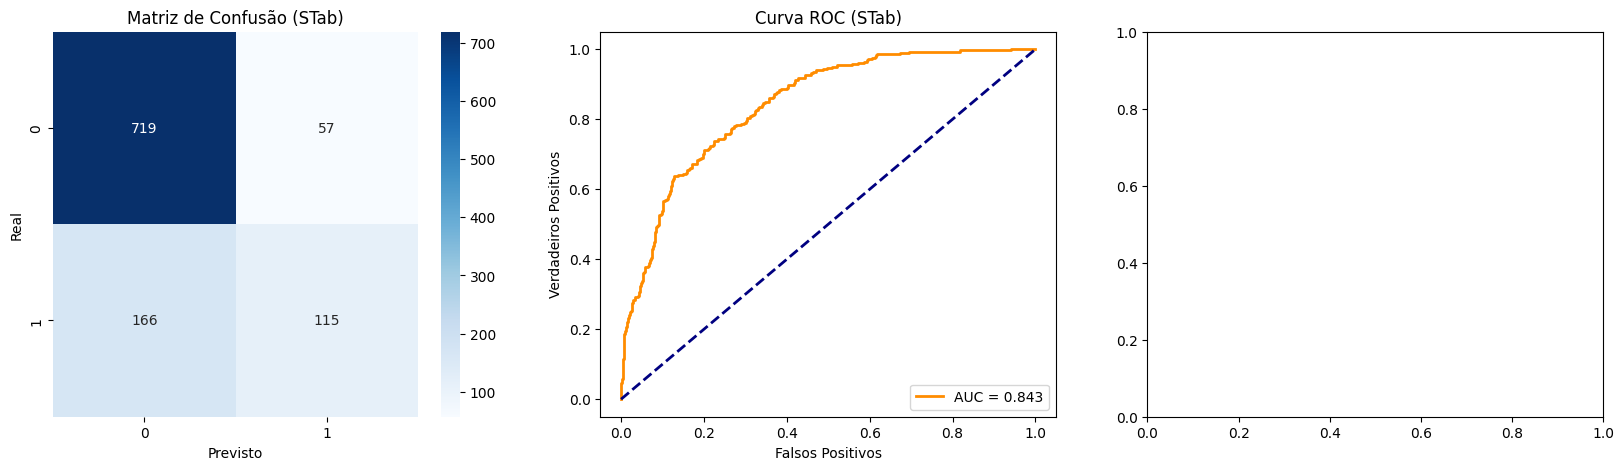

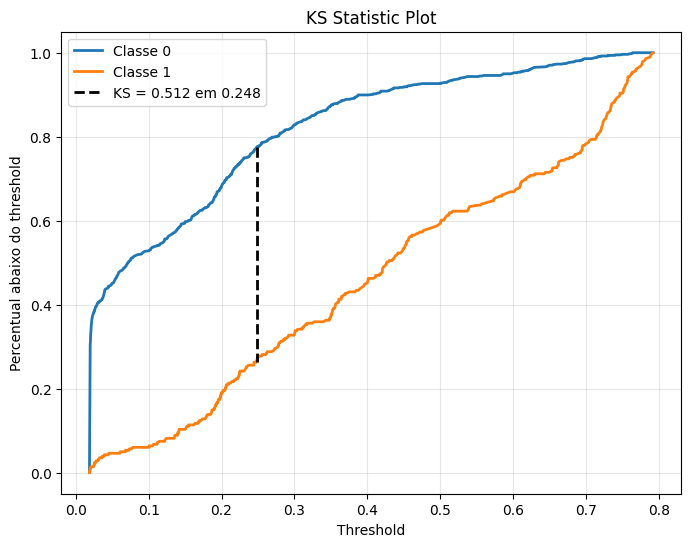

<Figure size 640x480 with 0 Axes>

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

# 1. Pré-processamento
print("Aplicando pré-processamento no conjunto de teste...")
X_test_proc = preprocessor.transform(X_test)

# ==========================================================
# 2. AVALIAÇÃO DO MODELO STab (TESTE)
# ==========================================================
print("\n=== Avaliando STab no Conjunto de Teste ===")

# Probabilidades e Previsões
y_probs_stab_test = np.ravel(best_model_stab.predict_proba(X_test_proc)[:, 1])
y_preds_stab_test = (y_probs_stab_test >= 0.5).astype(int)

# Calculando KS e Métricas
ks_stat_stab = ks_2samp(y_probs_stab_test[y_test == 0], y_probs_stab_test[y_test == 1]).statistic

metrics_stab = {
    "Accuracy": accuracy_score(y_test, y_preds_stab_test),
    "Precision": precision_score(y_test, y_preds_stab_test),
    "Recall": recall_score(y_test, y_preds_stab_test),
    "F1-score": f1_score(y_test, y_preds_stab_test),
    "ROC-AUC": roc_auc_score(y_test, y_probs_stab_test),
    "KS-Stat": ks_stat_stab
}

# Exibindo Tabela
print("\n=== Métricas de Desempenho: STab ===")
display(pd.DataFrame([metrics_stab], index=['STab']).round(4))

# ==========================================================
# 3. VISUALIZAÇÕES DO MODELO STab
# ==========================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 3.1 Matriz de Confusão
cm = confusion_matrix(y_test, y_preds_stab_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusão (STab)')
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

# 3.2 Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_probs_stab_test)
axes[1].plot(fpr, tpr, lw=2, color='darkorange', label=f"AUC = {metrics_stab['ROC-AUC']:.3f}")
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('Curva ROC (STab)')
axes[1].set_xlabel('Falsos Positivos')
axes[1].set_ylabel('Verdadeiros Positivos')
axes[1].legend(loc="lower right")

# 3.3 Curva KS
print("\n[STab] Gráfico da Curva KS:")
plot_ks_curve(y_test, y_probs_stab_test)

plt.tight_layout()
plt.show()


=== Avaliação Final no Conjunto de Teste ===

=== Métricas de Desempenho no Conjunto de Teste ===


,Accuracy,Precision,Recall,F1-score,ROC-AUC,KS-Stat
0,0.789,0.6686,0.4093,0.5077,0.8426,0.5124


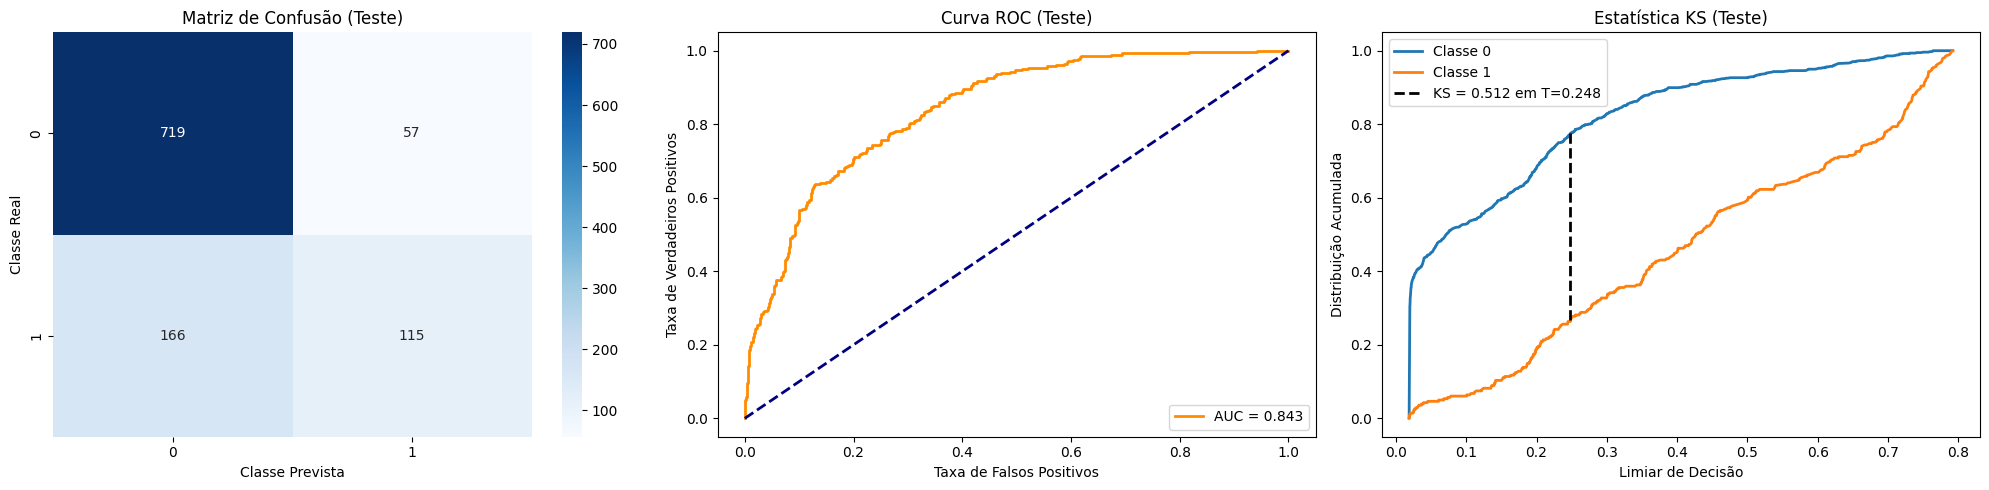

In [ ]:
# =====================================================================
# AVALIAÇÃO FINAL NO CONJUNTO DE TESTE
# =====================================================================
print("\n=== Avaliação Final no Conjunto de Teste ===")

# 1. Aplicar o pré-processamento no X_test (IMPORTANTE: apenas .transform())
# Isso garante que aplicamos a mesma escala do treino
X_test_proc = preprocessor.transform(X_test)

# 2. Gerar probabilidades e previsões
y_test_probs = np.ravel(best_model_stab.predict_proba(X_test_proc)[:, 1])
y_test_preds = (y_test_probs >= 0.5).astype(int)

# 3. Calcular Métricas para o Teste
metrics_test = {
    "Accuracy": accuracy_score(y_test, y_test_preds),
    "Precision": precision_score(y_test, y_test_preds),
    "Recall": recall_score(y_test, y_test_preds),
    "F1-score": f1_score(y_test, y_test_preds),
    "ROC-AUC": roc_auc_score(y_test, y_test_probs),
    "KS-Stat": ks_2samp(y_test_probs[y_test == 0], y_test_probs[y_test == 1]).statistic
}

print("\n=== Métricas de Desempenho no Conjunto de Teste ===")
display(pd.DataFrame([metrics_test]).round(4))

# =====================================================================
# GRÁFICOS PARA O CONJUNTO DE TESTE
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Matriz de Confusão
cm_test = confusion_matrix(y_test, y_test_preds)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusão (Teste)')
axes[0].set_xlabel('Classe Prevista')
axes[0].set_ylabel('Classe Real')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_test_probs)
axes[1].plot(fpr, tpr, lw=2, color='darkorange', label=f"AUC = {metrics_test['ROC-AUC']:.3f}")
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('Curva ROC (Teste)')
axes[1].set_xlabel('Taxa de Falsos Positivos')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1].legend(loc="lower right")

# 3. Curva KS
# Recriando a lógica da curva KS para o conjunto de teste
score_0_test = np.sort(y_test_probs[y_test == 0])
score_1_test = np.sort(y_test_probs[y_test == 1])
thresholds_test = np.sort(np.unique(y_test_probs))
ecdf_0_test = np.searchsorted(score_0_test, thresholds_test, side='right') / len(score_0_test)
ecdf_1_test = np.searchsorted(score_1_test, thresholds_test, side='right') / len(score_1_test)
diff_test = np.abs(ecdf_1_test - ecdf_0_test)
ks_idx_test = diff_test.argmax()
ks_val_test = diff_test.max()
ks_threshold_test = thresholds_test[ks_idx_test]

axes[2].plot(thresholds_test, ecdf_0_test, label='Classe 0', lw=2)
axes[2].plot(thresholds_test, ecdf_1_test, label='Classe 1', lw=2)
axes[2].vlines(ks_threshold_test, ecdf_0_test[ks_idx_test], ecdf_1_test[ks_idx_test],
               colors='black', linestyles='dashed', lw=2,
               label=f'KS = {ks_val_test:.3f} em T={ks_threshold_test:.3f}')
axes[2].set_title('Estatística KS (Teste)')
axes[2].set_xlabel('Limiar de Decisão')
axes[2].set_ylabel('Distribuição Acumulada')
axes[2].legend()

plt.tight_layout()
plt.show()

# **KAN classifier**

checkpoint directory created: ./model
saving model version 0.0
Treinando modelo KAN com parâmetros estáveis...


| train_loss: 6.32e-01 | test_loss: 6.44e-01 | reg: 3.51e+01 | : 100%|█| 200/200 [00:03<00:00, 64.51


saving model version 0.1

=== Métricas de Desempenho (KAN Classificação) ===


,Accuracy,Precision,Recall,F1-score,ROC-AUC,KS-Stat
0,0.7973,0.6375,0.5464,0.5885,0.8497,0.5683


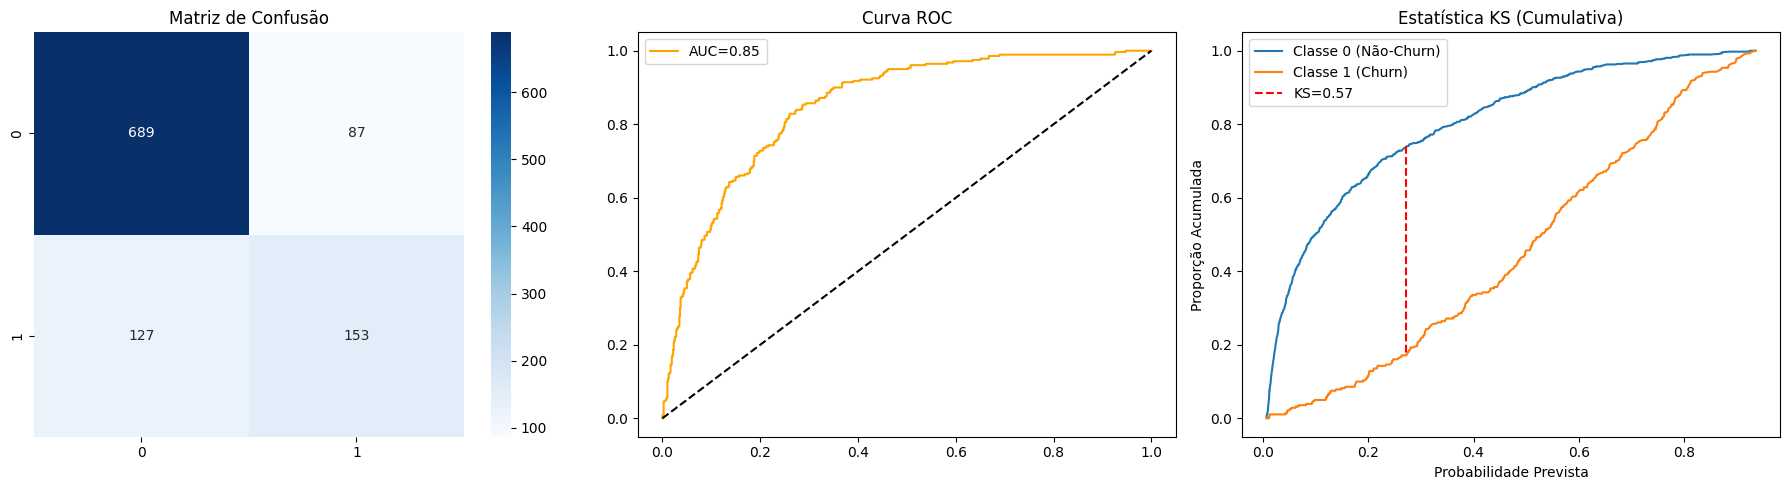

In [ ]:
import torch
import numpy as np
import pandas as pd
from kan import KAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregamento e Preparação
X_train, y_train, X_val, y_val, X_test, y_test = load_data('/content/drive/MyDrive/Projeto-Churn/data/train (1).csv', '/content/drive/MyDrive/Projeto-Churn/data/validation (1).csv', '/content/drive/MyDrive/Projeto-Churn/data/test (1).csv')
device = 'cuda' if torch.cuda.is_available() else 'cpu'

scaler = StandardScaler()
X_train_kan = torch.tensor(scaler.fit_transform(X_train.fillna(0)), dtype=torch.float32).to(device)
X_val_kan = torch.tensor(scaler.transform(X_val.fillna(0)), dtype=torch.float32).to(device)
y_train_kan = torch.tensor(y_train.values, dtype=torch.long).to(device)
y_val_kan = torch.tensor(y_val.values, dtype=torch.long).to(device)

# 2. Arquitetura baseada nos melhores parâmetros do Optuna para estabilidade
# Usando hidden_dim=8 e grid=3 para evitar explosão de gradiente
modelo_kan = KAN(width=[X_train_kan.shape[1], 8, 2], grid=3, k=2, device=device)

# 3. Funções de Métrica para o Loop de Treino
def train_acc():
    return torch.mean((torch.argmax(modelo_kan(X_train_kan), dim=1) == y_train_kan).float())
def test_acc():
    return torch.mean((torch.argmax(modelo_kan(X_val_kan), dim=1) == y_val_kan).float())

# 4. Treinamento
print("Treinando modelo KAN com parâmetros estáveis...")
modelo_kan.fit(
    {'train_input': X_train_kan, 'train_label': y_train_kan,
     'test_input': X_val_kan, 'test_label': y_val_kan},
    opt='Adam',
    steps=200,
    lr=0.0043, # Valor do melhor trial
    loss_fn=torch.nn.CrossEntropyLoss(),
    metrics=(train_acc, test_acc),
    update_grid=False
)

# 5. Previsão e Métricas
def get_probs(model, x):
    logits = model(x)
    # Ajustado dim de 8 para 1
    probs = torch.softmax(logits, dim=1)
    return probs[:, 1].detach().cpu().numpy().flatten()

y_probs = get_probs(modelo_kan, X_val_kan)
y_preds = (y_probs >= 0.5).astype(int)

# 6. Exibição de Métricas
metrics = {
    "Accuracy": accuracy_score(y_val, y_preds),
    "Precision": precision_score(y_val, y_preds, zero_division=0),
    "Recall": recall_score(y_val, y_preds),
    "F1-score": f1_score(y_val, y_preds),
    "ROC-AUC": roc_auc_score(y_val, y_probs),
    "KS-Stat": ks_2samp(y_probs[y_val == 0], y_probs[y_val == 1]).statistic
}

print("\n=== Métricas de Desempenho (KAN Classificação) ===")
display(pd.DataFrame([metrics]).round(4))

# 7. Gráficos (ROC, KS, Matriz de Confusão)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A. Matriz de Confusão
sns.heatmap(confusion_matrix(y_val, y_preds), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Matriz de Confusão')

# B. Curva ROC
fpr, tpr, _ = roc_curve(y_val, y_probs)
axes[1].plot(fpr, tpr, color='orange', label=f"AUC={metrics['ROC-AUC']:.2f}")
axes[1].plot([0,1], [0,1], 'k--')
axes[1].set_title('Curva ROC')
axes[1].legend()

# C. Gráfico da Estatística KS (Curva Cumulativa)
# Ordenar probabilidades para plotar as curvas de distribuição acumulada (ECDF)
sorted_probs = np.sort(y_probs)
ecdf_0 = [np.mean(y_probs[y_val == 0] <= p) for p in sorted_probs]
ecdf_1 = [np.mean(y_probs[y_val == 1] <= p) for p in sorted_probs]

axes[2].plot(sorted_probs, ecdf_0, label='Classe 0 (Não-Churn)')
axes[2].plot(sorted_probs, ecdf_1, label='Classe 1 (Churn)')

# Encontrar o ponto de distância máxima (KS)
diffs = np.abs(np.array(ecdf_0) - np.array(ecdf_1))
max_idx = np.argmax(diffs)
axes[2].vlines(sorted_probs[max_idx], ecdf_0[max_idx], ecdf_1[max_idx], color='red', linestyle='--', label=f'KS={metrics["KS-Stat"]:.2f}')

axes[2].set_title('Estatística KS (Cumulativa)')
axes[2].set_xlabel('Probabilidade Prevista')
axes[2].set_ylabel('Proporção Acumulada')
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
import optuna
import torch
import numpy as np
from kan import KAN
from scipy.stats import ks_2samp

# Função objetivo para o Optuna
def objective(trial):
    # Definindo hiperparâmetros para tunagem
    hidden_dim = trial.suggest_categorical("hidden_dim", [8, 16])
    grid = trial.suggest_int("grid", 3, 5) # Reduzido para maior estabilidade
    k = trial.suggest_int("k", 2, 3)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)

    try:
        # Modelo
        model = KAN(width=[X_train_kan.shape[1], hidden_dim, 2], grid=grid, k=k, device=device)

        # Treino
        model.fit(
            {'train_input': X_train_kan, 'train_label': y_train_kan,
             'test_input': X_val_kan, 'test_label': y_val_kan},
            opt='Adam',
            steps=100,
            lr=lr,
            loss_fn=torch.nn.CrossEntropyLoss(),
            update_grid=False # Mantendo o grid estático para evitar NaNs repentinos
        )

        # Predição para KS
        logits = model(X_val_kan)
        probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy().flatten()

        # Verificar se houve explosão numérica (NaN)
        if np.isnan(probs).any():
            return 0.0

        # Métrica de Otimização: KS
        ks_stat = ks_2samp(probs[y_val == 0], probs[y_val == 1]).statistic
        return float(ks_stat)

    except Exception as e:
        print(f"Erro no Trial: {e}")
        return 0.0

# Executar a tunagem
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10) # n_trials reduzido para teste inicial

print(f"Melhores parâmetros: {study.best_params}")

[I 2026-07-03 04:31:42,829] A new study created in memory with name: no-name-5e9170ae-ca68-4aef-a510-6e0c4f9067b3


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 6.43e-01 | test_loss: 6.52e-01 | reg: 3.06e+01 | : 100%|█| 100/100 [00:01<00:00, 80.14
[I 2026-07-03 04:31:44,170] Trial 0 finished with value: 0.5552650957290133 and parameters: {'hidden_dim': 8, 'grid': 3, 'k': 2, 'lr': 0.004342210322394755}. Best is trial 0 with value: 0.5552650957290133.


saving model version 0.1
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 6.75e-01 | test_loss: 6.83e-01 | reg: 4.20e+01 | : 100%|█| 100/100 [00:01<00:00, 69.51
[I 2026-07-03 04:31:45,776] Trial 1 finished with value: 0.4810014727540501 and parameters: {'hidden_dim': 16, 'grid': 4, 'k': 3, 'lr': 0.0008412287716901156}. Best is trial 0 with value: 0.5552650957290133.


...

saving model version 0.1
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 6.50e-01 | test_loss: 6.59e-01 | reg: 3.06e+01 | : 100%|█| 100/100 [00:01<00:00, 98.31
[I 2026-07-03 04:31:54,791] Trial 8 finished with value: 0.5281296023564065 and parameters: {'hidden_dim': 8, 'grid': 4, 'k': 2, 'lr': 0.0024463440371894386}. Best is trial 0 with value: 0.5552650957290133.


saving model version 0.1
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 6.45e-01 | test_loss: 6.53e-01 | reg: 4.64e+01 | : 100%|█| 100/100 [00:01<00:00, 88.02
[I 2026-07-03 04:31:56,049] Trial 9 finished with value: 0.5516936671575847 and parameters: {'hidden_dim': 16, 'grid': 3, 'k': 3, 'lr': 0.002695407612426456}. Best is trial 0 with value: 0.5552650957290133.


saving model version 0.1
Melhores parâmetros: {'hidden_dim': 8, 'grid': 3, 'k': 2, 'lr': 0.004342210322394755}


# **Outros testes**


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# 1. Definindo as colunas numéricas que sobraram no seu X_limpo
num_cols_originais = ['tenure', 'MonthlyCharges', 'TotalCharges']
# Filtramos apenas as que existem (pois algumas podem ter sido removidas)
num_cols_filtradas = [c for c in num_cols_originais if c in X_limpo.columns]

# 2. Definindo colunas categóricas (todas que restaram e não são numéricas)
cat_cols_filtradas = [c for c in X_limpo.columns if c not in num_cols_filtradas]

# 3. Criando o novo preprocessor
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols_filtradas),
    ('cat', cat_pipeline, cat_cols_filtradas)
])

# 4. Processando os dados limpos
X_proc = preprocessor.fit_transform(X_limpo)

# Atualizando os índices categóricos para o modelo STab
num_cols_len = len(num_cols_filtradas)
cat_idxs = list(range(num_cols_len, X_proc.shape[1]))

print(f"Pipeline reconstruído com sucesso!")
print(f"Colunas numéricas: {num_cols_filtradas}")
print(f"Colunas categóricas: {len(cat_cols_filtradas)}")

Pipeline reconstruído com sucesso!
Colunas numéricas: ['tenure', 'MonthlyCharges', 'TotalCharges']
Colunas categóricas: 16



=== Treinamento TabPFNv2 com StratifiedKFold ===
00:00 Fitting... \

00:05 Fitting... Done!
00:00 Predicting... \

00:02 Predicting... Done!
Fold 1 | KS: 0.6263
00:06 Fitting... Done!
00:03 Predicting... Done!
Fold 2 | KS: 0.5247
00:06 Fitting... Done!
00:03 Predicting... Done!
Fold 3 | KS: 0.6071
00:06 Fitting... Done!
00:03 Predicting... Done!
Fold 4 | KS: 0.4522
00:06 Fitting... Done!
00:03 Predicting... Done!
Fold 5 | KS: 0.5819
00:06 Fitting... Done!
00:05 Predicting... Done!
Fold 6 | KS: 0.6011
00:06 Fitting... Done!
00:03 Predicting... Done!
Fold 7 | KS: 0.4995
00:06 Fitting... Done!
00:04 Predicting... Done!
Fold 8 | KS: 0.5572
00:06 Fitting... Done!
00:03 Predicting... Done!
Fold 9 | KS: 0.7056
00:06 Fitting... Done!
00:03 Predicting... Done!
Fold 10 | KS: 0.5062
00:06 Fitting... Done!
00:05 Predicting... Done!
Fold 11 | KS: 0.6707
00:06 Fitting... Done!
00:04 Predicting... Done!
Fold 12 | KS: 0.6684
00:06 Fitting... Done!
00:03 Predicting... Done!
Fold 13 | KS: 0.5681
00:06 Fitting... Done!
00:03 Predicting... Done!
Fold 14 | KS: 0.5819
00:06 Fitting... Done!
00:03 Predicting... Done!
Fol

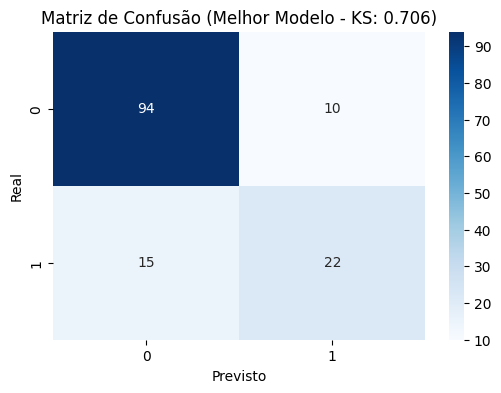

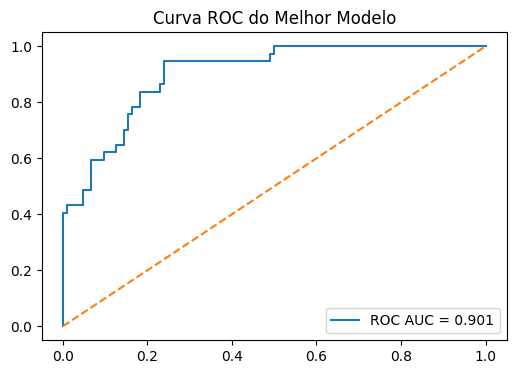

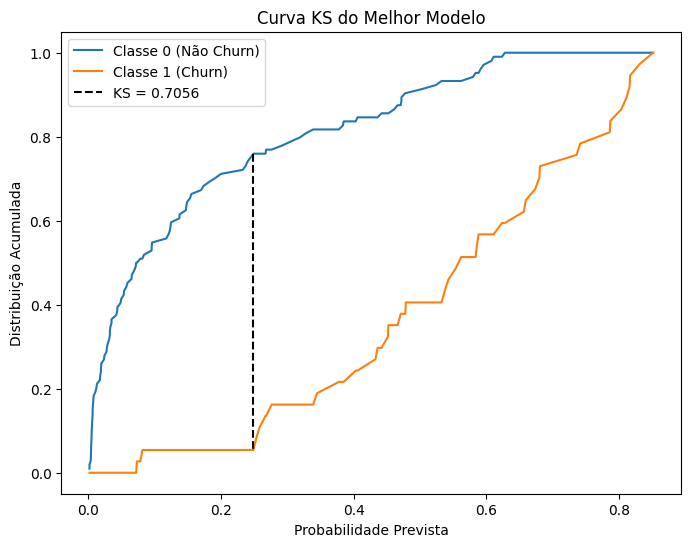

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, classification_report
from scipy.stats import ks_2samp
from tabpfn_client import TabPFNClassifier

# ==========================================================
# 2. TREINAMENTO COM RASTREAMENTO DO MELHOR MODELO
# ==========================================================
print("\n=== Treinamento TabPFNv2 com StratifiedKFold ===")

skf = StratifiedKFold(n_splits=50, shuffle=True, random_state=42)
resultados_ks = []

# Variáveis para rastrear o melhor modelo
melhor_ks = -1
melhor_clf = None
melhor_X_test = None
melhor_y_test = None
melhor_y_prob = None

for fold, (train_index, test_index) in enumerate(skf.split(X_limpo, Y_limpo)):
    X_train_fold, X_test_fold = X_limpo.iloc[train_index], X_limpo.iloc[test_index]
    y_train_fold, y_test_fold = Y_limpo.iloc[train_index], Y_limpo.iloc[test_index]

    clf_tab = TabPFNClassifier(ignore_pretraining_limits=True)
    clf_tab.fit(X_train_fold, y_train_fold)

    pred_proba_test = np.ravel(clf_tab.predict_proba(X_test_fold)[:, 1])
    ks_fold = ks_2samp(pred_proba_test[y_test_fold == 0], pred_proba_test[y_test_fold == 1]).statistic
    resultados_ks.append(ks_fold)

    print(f"Fold {fold+1} | KS: {ks_fold:.4f}")

    # Lógica para salvar o melhor modelo
    if ks_fold > melhor_ks:
        melhor_ks = ks_fold
        melhor_clf = clf_tab
        melhor_X_test = X_test_fold
        melhor_y_test = y_test_fold
        melhor_y_prob = pred_proba_test

print(f"\nKS Médio (50 Folds): {np.mean(resultados_ks):.4f}")
print(f"Melhor KS encontrado: {melhor_ks:.4f}")

# ==========================================================
# 3. GRÁFICOS E MÉTRICAS DO MELHOR MODELO
# ==========================================================

# Previsões binárias do melhor modelo
y_pred = (melhor_y_prob >= 0.5).astype(int)

print("\n=== Métricas Detalhadas do Melhor Modelo (Fold Vencedor) ===")
print(classification_report(melhor_y_test, y_pred))

# Plot Matriz de Confusão
plt.figure(figsize=(6, 4))
cm = confusion_matrix(melhor_y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de Confusão (Melhor Modelo - KS: {melhor_ks:.3f})')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

# Plot Curva ROC
plt.figure(figsize=(6, 4))
fpr, tpr, _ = roc_curve(melhor_y_test, melhor_y_prob)
auc = roc_auc_score(melhor_y_test, melhor_y_prob)
plt.plot(fpr, tpr, label=f'ROC AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Curva ROC do Melhor Modelo')
plt.legend()
plt.show()

# Plot Curva KS
plt.figure(figsize=(8, 6))
score_0 = np.sort(melhor_y_prob[melhor_y_test == 0])
score_1 = np.sort(melhor_y_prob[melhor_y_test == 1])
thresholds = np.sort(np.unique(melhor_y_prob))

ecdf_0 = np.searchsorted(score_0, thresholds, side='right') / len(score_0)
ecdf_1 = np.searchsorted(score_1, thresholds, side='right') / len(score_1)

diff = np.abs(ecdf_1 - ecdf_0)
idx = diff.argmax()

plt.plot(thresholds, ecdf_0, label='Classe 0 (Não Churn)')
plt.plot(thresholds, ecdf_1, label='Classe 1 (Churn)')
plt.vlines(thresholds[idx], ecdf_0[idx], ecdf_1[idx], colors='black', linestyles='dashed', label=f'KS = {melhor_ks:.4f}')
plt.title('Curva KS do Melhor Modelo')
plt.xlabel('Probabilidade Prevista')
plt.ylabel('Distribuição Acumulada')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report
from scipy.stats import ks_2samp

def imprimir_metricas_detalhadas(y_true, y_prob, y_pred):
    # Calcula KS
    ks_stat, _ = ks_2samp(y_prob[y_true == 0], y_prob[y_true == 1])

    # Calcula AUC
    auc = roc_auc_score(y_true, y_prob)

    print(f"Estatística Kolmogorov-Smirnov (KS): {ks_stat:.4f}")
    print(f"Área sob a Curva ROC (AUROC): {auc:.4f}")
    print("\nRelatório de Classificação:")
    print(classification_report(y_true, y_pred))

    # Matriz de Confusão
    plt.figure(figsize=(6,4))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusão')
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()

def plot_ks_curve_full(y_true, y_score):
    plt.figure(figsize=(8,6))
    score_0 = np.sort(y_score[y_true == 0])
    score_1 = np.sort(y_score[y_true == 1])
    thresholds = np.sort(np.unique(y_score))

    ecdf_0 = np.searchsorted(score_0, thresholds, side='right') / len(score_0)
    ecdf_1 = np.searchsorted(score_1, thresholds, side='right') / len(score_1)

    diff = np.abs(ecdf_1 - ecdf_0)
    ks = diff.max()
    idx = diff.argmax()

    plt.plot(thresholds, ecdf_0, label='Classe 0 (Não Churn)')
    plt.plot(thresholds, ecdf_1, label='Classe 1 (Churn)')
    plt.vlines(thresholds[idx], ecdf_0[idx], ecdf_1[idx], colors='black',
               linestyles='dashed', label=f'KS = {ks:.4f}')
    plt.title('Curva KS Detalhada')
    plt.xlabel('Probabilidade Prevista')
    plt.ylabel('Distribuição Acumulada')
    plt.legend()
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from scipy.stats import ks_2samp

# 1. Eng. de Atributos: Separando Train/Val de Teste
print("Unindo Treino e Validação e isolando Teste...")

# União apenas do que será usado para treino/ajuste (CV)
X_train_val = pd.concat([X_train, X_val], ignore_index=True)
Y_train_val = pd.concat([y_train, y_val], ignore_index=True)

# Conjunto de Teste separado (será usado apenas no final)
X_test_final = X_test.copy()
Y_test_final = y_test.copy()

# 2. Remoção de ruído (aplicada em ambos para manter consistência)
colunas_a_dropar = ['StreamingTV', 'StreamingMovies', 'MultipleLines', 'PaperlessBilling', 'InternetService']

X_train_val = X_train_val.drop(columns=colunas_a_dropar, errors='ignore')
X_test_final = X_test_final.drop(columns=colunas_a_dropar, errors='ignore')

print(f"Dimensão Treino/Val: X={X_train_val.shape}, Y={Y_train_val.shape}")
print(f"Dimensão Teste Final: X={X_test_final.shape}, Y={Y_test_final.shape}")

Unindo Treino e Validação e isolando Teste...
Dimensão Treino/Val: X=(5986, 13), Y=(5986,)
Dimensão Teste Final: X=(1057, 13), Y=(1057,)



=== Treinamento com CV e Checagem no Teste ===
00:00 Fitting... \

00:05 Fitting... Done!
00:00 Predicting... \

00:05 Predicting... Done!
Fold 1 | KS no Teste: 0.5355
00:00 Fitting... \

00:15 Fitting... Done!
00:00 Predicting... \

00:14 Predicting... Done!
Fold 2 | KS no Teste: 0.5327
00:00 Fitting... \

...

00:05 Fitting... Done!
00:00 Predicting... \

00:03 Predicting... Done!
Fold 9 | KS no Teste: 0.5353
00:00 Fitting... \

00:05 Fitting... Done!
00:00 Predicting... \

00:03 Predicting... Done!
Fold 10 | KS no Teste: 0.5375

=== Métricas Detalhadas do Melhor Modelo ===


,Accuracy,Precision,Recall,F1-score,ROC-AUC,KS-Stat
0,0.7966,0.6602,0.484,0.5585,0.8462,0.5437


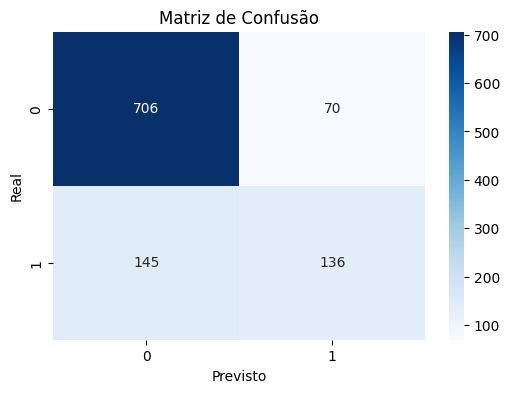

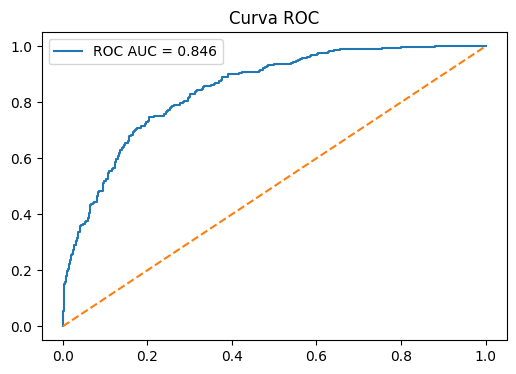

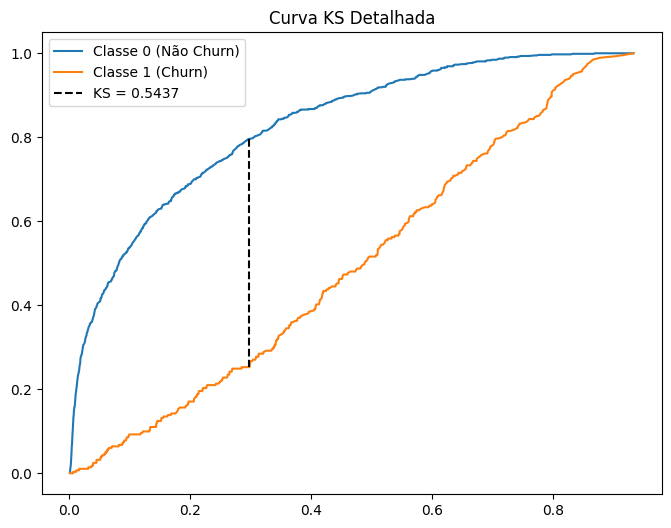

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)
from tabpfn_client import TabPFNClassifier

# ==========================================================
# 1. FUNÇÕES DE VISUALIZAÇÃO E MÉTRICAS
# ==========================================================
def exibir_resultados_finais(y_true, y_prob, y_pred, ks_val):
    # Cálculo das métricas
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "KS-Stat": ks_val
    }

    # Exibir Tabela de Métricas
    print("\n=== Métricas Detalhadas do Melhor Modelo ===")
    display(pd.DataFrame([metrics]).round(4))

    # Matriz de Confusão
    plt.figure(figsize=(6,4))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusão')
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()

    # Curva ROC
    plt.figure(figsize=(6,4))
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr, label=f"ROC AUC = {metrics['ROC-AUC']:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.title('Curva ROC')
    plt.legend()
    plt.show()

def plot_ks_curve_full(y_true, y_score):
    plt.figure(figsize=(8,6))
    score_0 = np.sort(y_score[y_true == 0])
    score_1 = np.sort(y_score[y_true == 1])
    thresholds = np.sort(np.unique(y_score))

    ecdf_0 = np.searchsorted(score_0, thresholds, side='right') / len(score_0)
    ecdf_1 = np.searchsorted(score_1, thresholds, side='right') / len(score_1)

    diff = np.abs(ecdf_1 - ecdf_0)
    ks = diff.max()
    idx = diff.argmax()

    plt.plot(thresholds, ecdf_0, label='Classe 0 (Não Churn)')
    plt.plot(thresholds, ecdf_1, label='Classe 1 (Churn)')
    plt.vlines(thresholds[idx], ecdf_0[idx], ecdf_1[idx], colors='black',
               linestyles='dashed', label=f'KS = {ks:.4f}')
    plt.title('Curva KS Detalhada')
    plt.legend()
    plt.show()

# ==========================================================
# 2. TREINAMENTO COM RASTREAMENTO DO MELHOR KS NO TESTE
# ==========================================================
print("\n=== Treinamento com CV e Checagem no Teste ===")

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

melhor_ks_teste = -1
melhor_clf = None
melhor_y_prob_teste = None
melhor_y_pred_teste = None

for fold, (train_index, val_index) in enumerate(skf.split(X_train_val, Y_train_val)):
    X_fold_train = X_train_val.iloc[train_index]
    y_fold_train = Y_train_val.iloc[train_index]

    clf = TabPFNClassifier(ignore_pretraining_limits=True)
    clf.fit(X_fold_train, y_fold_train)

    # Checagem no CONJUNTO DE TESTE FINAL
    y_test_proba = np.ravel(clf.predict_proba(X_test_final)[:, 1])
    y_test_pred = (y_test_proba >= 0.5).astype(int)

    ks_teste = ks_2samp(y_test_proba[Y_test_final == 0], y_test_proba[Y_test_final == 1]).statistic

    print(f"Fold {fold+1} | KS no Teste: {ks_teste:.4f}")

    # Salvar o modelo se for o melhor KS no teste
    if ks_teste > melhor_ks_teste:
        melhor_ks_teste = ks_teste
        melhor_clf = clf
        melhor_y_prob_teste = y_test_proba
        melhor_y_pred_teste = y_test_pred

# ==========================================================
# 3. EXIBIÇÃO DOS RESULTADOS DO MELHOR MODELO
# ==========================================================
exibir_resultados_finais(Y_test_final, melhor_y_prob_teste, melhor_y_pred_teste, melhor_ks_teste)
plot_ks_curve_full(Y_test_final, melhor_y_prob_teste)